Rene Dvash 213468200
Tagreed Assi 213232895

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [2]:
# 1. Load and Preprocess CIFAR-10 Data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Split training data into training and validation sets
validation_split = 0.2  # Use 20% of the training data for validation
split_index = int(len(x_train) * (1 - validation_split))
x_val, y_val = x_train[split_index:], y_train[split_index:]
x_train_new, y_train_new = x_train[:split_index], y_train[:split_index]

# Get the input shape
input_shape = x_train_new.shape[1:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
# 2. Define the Model Architecture & Create the Model Instance

model = keras.Sequential([
layers.Input(shape=input_shape),

layers.BatchNormalization(),
layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Dropout(0.2),

layers.Conv2D(68, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Conv2D(68, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.3),

layers.Conv2D(82, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Conv2D(82, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.4),

layers.Flatten(),
layers.Dense(95, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Dense(89, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
layers.BatchNormalization(),
layers.Dropout(0.5),
layers.Dense(num_classes, activation='softmax'),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 32, 32, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 68)     │        19,652 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 68)     │           272 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 68)     │        41,684 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 68)     │           272 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 68)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 68)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 82)     │        50,266 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 82)     │           328 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 82)     │        60,598 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 82)     │           328 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 82)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 82)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 95)             │       498,655 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 95)             │           380 │
│ (BatchNormalization)            │                        │             

 Total params: 692,647 (2.64 MB)

 Trainable params: 691,545 (2.64 MB)

 Non-trainable params: 1,102 (4.30 KB)

In [4]:
# 3. Compile the Model
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model with Validation Data
epochs = 30
batch_size = 32

history = model.fit(x_train_new, y_train_new,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_val, y_val))

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.2665 - loss: 2.9032 - val_accuracy: 0.4749 - val_loss: 2.0309
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.4556 - loss: 2.0671 - val_accuracy: 0.5573 - val_loss: 1.7797
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.5316 - loss: 1.8568 - val_accuracy: 0.5778 - val_loss: 1.7051
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5772 - loss: 1.7234 - val_accuracy: 0.6531 - val_loss: 1.4953
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6154 - loss: 1.5935 - val_accuracy: 0.6829 - val_loss: 1.3868
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6448 - loss: 1.5006 - val_accuracy: 0.7078 - val_loss: 1.2939
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6741 - loss: 1.4152 - val_accuracy: 0.7121 - val_loss: 1.2651
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6934 -

In [5]:
# 5. Evaluate the Model on the Test Set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Print Final Validation Metrics
val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.3f}")
print(f"Validation Accuracy: {val_accuracy:.3f}")

# Print Final Training Metrics
train_loss, train_accuracy = model.evaluate(x_train_new, y_train_new, verbose=0)
print(f"Training Loss: {train_loss:.3f}")
print(f"Training Accuracy: {train_accuracy:.3f}")

Test Loss: 0.797
Test Accuracy: 0.826
Validation Loss: 0.785
Validation Accuracy: 0.828
Training Loss: 0.445
Training Accuracy: 0.947


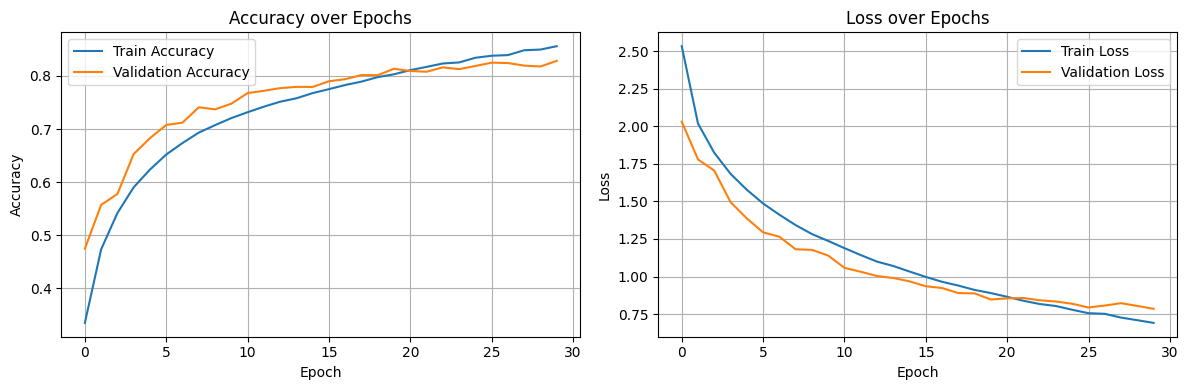

In [6]:
# 6. Visualize Training and Validation Performance
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()